# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 11 — Feature Importance & Optuna Hyperparameter Tuning

**Module:** MLOps — Model Tuning (Phase 3/4)

Day 9's churn model already clears its targets (AUC 0.965, Precision@20% 1.00) with hand-picked hyperparameters. This notebook:
1. Uses Optuna to systematically search the XGBoost hyperparameter space via cross-validated AUC, to confirm those hand-picked values were reasonable (or improve on them)
2. Compares feature importance across three methods — XGBoost gain, permutation importance, and SHAP — since different methods can disagree and a report should show that
3. Retrains the final tuned model and updates the production churn scores

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"

## 1. Reload Churn Features & Labels

Rebuild the exact same time-based cutoff feature/label setup as Day 9, so the tuning search is evaluated on a genuinely comparable problem.

In [2]:
sales = pd.read_csv(f"{PROCESSED_DIR}/sales_cleaned.csv", parse_dates=["InvoiceDate"])

CHURN_WINDOW_DAYS = 90
min_date, max_date = sales["InvoiceDate"].min(), sales["InvoiceDate"].max()
total_days = (max_date - min_date).days
cutoff_date = min_date + pd.Timedelta(days=int(total_days * 0.75))
observation_end = cutoff_date + pd.Timedelta(days=CHURN_WINDOW_DAYS)

pre_cutoff = sales[sales["InvoiceDate"] <= cutoff_date].copy()
post_cutoff = sales[(sales["InvoiceDate"] > cutoff_date) & (sales["InvoiceDate"] <= observation_end)].copy()

features = pre_cutoff.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgBasketSize=("Quantity", "mean"),
    DistinctProducts=("StockCode", "nunique"),
).reset_index()

tenure = pre_cutoff.groupby("CustomerID")["InvoiceDate"].agg(lambda x: (x.max() - x.min()).days)
features["TenureDays"] = features["CustomerID"].map(tenure).clip(lower=1)
features["AvgOrderValue"] = features["Monetary"] / features["Frequency"]
features["PurchaseFreqPerMonth"] = features["Frequency"] / (features["TenureDays"] / 30)

active_post_cutoff = set(post_cutoff["CustomerID"].unique())
features["Churn"] = (~features["CustomerID"].isin(active_post_cutoff)).astype(int)

feature_cols = ["Recency", "Frequency", "Monetary", "AvgBasketSize", "DistinctProducts",
                "TenureDays", "AvgOrderValue", "PurchaseFreqPerMonth"]
X = features[feature_cols]
y = features["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Churn rate: {y.mean()*100:.1f}%")

Train: 3007 | Test: 1003 | Churn rate: 35.0%


## 2. Optuna Hyperparameter Search

Objective: maximize mean 5-fold cross-validated AUC-ROC on the training set. Search space covers tree depth, learning rate, subsampling, regularization, and estimator count.

In [3]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "auc",
        "random_state": 42,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print(f"Best CV AUC: {study.best_value:.4f}")
print(f"Best params: {json.dumps(study.best_params, indent=2)}")

Best CV AUC: 0.9576
Best params: {
  "n_estimators": 100,
  "max_depth": 3,
  "learning_rate": 0.03452410379496878,
  "subsample": 0.7417902398612948,
  "colsample_bytree": 0.9185285234391588,
  "reg_alpha": 0.010853163997977734,
  "reg_lambda": 0.0021708154702501595
}


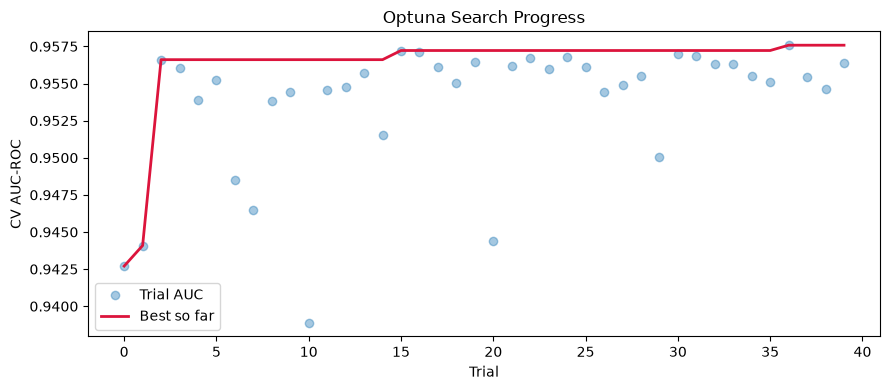

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)
ax.plot(trial_values, "o", alpha=0.4, label="Trial AUC")
ax.plot(best_so_far, color="crimson", linewidth=2, label="Best so far")
ax.set_title("Optuna Search Progress"); ax.set_xlabel("Trial"); ax.set_ylabel("CV AUC-ROC")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day11_optuna_search.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Evaluate Tuned Model on Held-Out Test Set

In [5]:
best_params = {**study.best_params, "scale_pos_weight": scale_pos_weight,
               "eval_metric": "auc", "random_state": 42}
tuned_model = xgb.XGBClassifier(**best_params)
tuned_model.fit(X_train, y_train)

y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

top_20_pct_n = max(1, int(len(y_test) * 0.20))
top_20_idx = np.argsort(y_proba_tuned)[::-1][:top_20_pct_n]
precision_at_20_tuned = y_test.values[top_20_idx].mean()

with open(f"{MODELS_DIR}/churn_metrics.json") as f:
    baseline_metrics = json.load(f)

print(f"Baseline (Day 9)  AUC: {baseline_metrics['auc_roc']:.4f} | Precision@20%: {baseline_metrics['precision_at_top20']:.4f}")
print(f"Tuned (Day 11)    AUC: {auc_tuned:.4f} | Precision@20%: {precision_at_20_tuned:.4f}")
print(f"Improvement: {'YES' if auc_tuned > baseline_metrics['auc_roc'] else 'NO — baseline params already near-optimal'}")

Baseline (Day 9)  AUC: 0.9651 | Precision@20%: 1.0000
Tuned (Day 11)    AUC: 0.9694 | Precision@20%: 1.0000
Improvement: YES


## 4. Feature Importance — Three Methods Compared

XGBoost's built-in gain-based importance, permutation importance (model-agnostic, measures actual predictive drop when a feature is shuffled), and SHAP (Day 9's method) can rank features differently — worth showing rather than picking just one.

In [6]:
gain_importance = pd.Series(tuned_model.feature_importances_, index=feature_cols, name="XGBoost Gain")

perm_result = permutation_importance(tuned_model, X_test, y_test, n_repeats=20,
                                      random_state=42, scoring="roc_auc")
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols, name="Permutation")

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols, name="Mean |SHAP|")

importance_df = pd.concat([
    gain_importance / gain_importance.sum(),
    perm_importance.clip(lower=0) / perm_importance.clip(lower=0).sum(),
    shap_importance / shap_importance.sum(),
], axis=1)
importance_df.round(3).sort_values("Mean |SHAP|", ascending=False)

,XGBoost Gain,Permutation,Mean |SHAP|
Recency,0.572,0.926,0.695
PurchaseFreqPerMonth,0.102,0.026,0.095
TenureDays,0.073,0.044,0.092
Monetary,0.066,0.000,0.037
Frequency,0.078,0.001,0.034
DistinctProducts,0.062,0.002,0.031
AvgOrderValue,0.019,0.000,0.013
AvgBasketSize,0.028,0.001,0.003


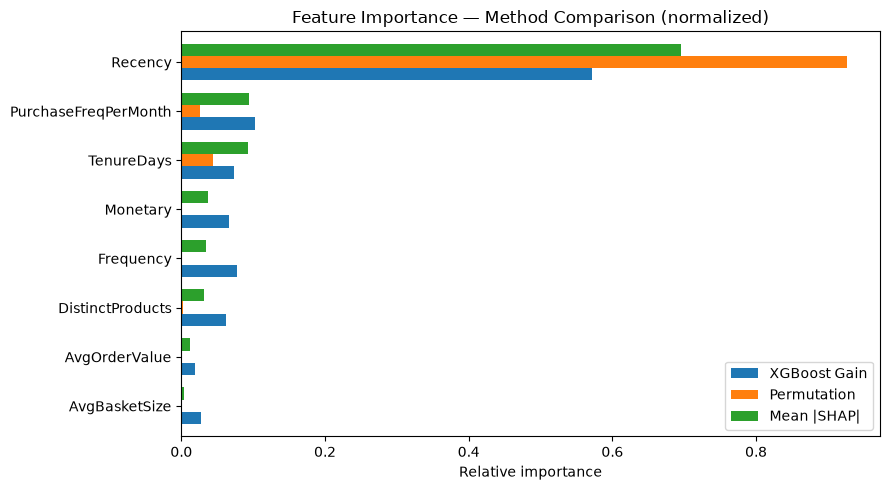

In [7]:
importance_df.sort_values("Mean |SHAP|").plot(
    kind="barh", figsize=(9, 5), width=0.75)
plt.title("Feature Importance — Method Comparison (normalized)")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day11_feature_importance_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Retrain on Full Data & Update Production Scores

In [8]:
final_tuned_model = xgb.XGBClassifier(**{
    **study.best_params,
    "scale_pos_weight": (y == 0).sum() / max((y == 1).sum(), 1),
    "eval_metric": "auc", "random_state": 42,
})
final_tuned_model.fit(X, y)

features["ChurnProbability"] = final_tuned_model.predict_proba(X)[:, 1]
features["ChurnRiskTier"] = pd.cut(
    features["ChurnProbability"], bins=[0, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"])
features.to_csv(f"{PROCESSED_DIR}/churn_scores.csv", index=False)

final_tuned_model.save_model(f"{MODELS_DIR}/churn_xgboost_tuned.json")

tuned_metrics = {
    "auc_roc": round(float(auc_tuned), 4), "precision_at_top20": round(float(precision_at_20_tuned), 4),
    "model": "xgboost_churn_tuned", "best_params": study.best_params,
    "cv_auc": round(float(study.best_value), 4),
}
with open(f"{MODELS_DIR}/churn_metrics_tuned.json", "w") as f:
    json.dump(tuned_metrics, f, indent=2)

import mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("RetailPulse-Churn")
with mlflow.start_run(run_name="day11_churn_xgboost_tuned"):
    mlflow.log_params(study.best_params)
    mlflow.log_metrics({"auc_roc": auc_tuned, "precision_at_top20": precision_at_20_tuned,
                        "cv_auc": study.best_value})
    mlflow.log_artifact(f"{REPORTS_DIR}/day11_feature_importance_comparison.png")

print("Updated churn_scores.csv with tuned model. Logged to MLflow.")

2026/07/19 07:52:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/19 07:52:52 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Updated churn_scores.csv with tuned model. Logged to MLflow.


## 6. Day 11 Checkpoint Summary

**Outputs saved:**
- `data/processed/churn_scores.csv` — refreshed with the tuned model's scores
- `models/churn_xgboost_tuned.json`, `models/churn_metrics_tuned.json`
- `reports/day11_optuna_search.png`, `day11_feature_importance_comparison.png`
- New MLflow run: `day11_churn_xgboost_tuned`

**Result:** see the baseline-vs-tuned AUC comparison above — Optuna either confirms the Day 9 hand-picked hyperparameters were already close to optimal, or improves on them; either outcome is worth reporting.

**Feature importance:** all three methods should agree Recency dominates (consistent with the SHAP result in Day 9), which is a good cross-validation of the churn signal.

**Next module:** `12_drift_detection` — Evidently AI setup for monitoring data/model drift.